# Task 5: Capstone — Redesigning for the Human Visual System (`gapminder.csv`)

Redesigning global life expectancy trajectories by applying visual perception principles:
Preattentive pop-out, Gestalt grouping, cognitive load reduction, and channel effectiveness.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('data/gapminder.csv')
print(f"Total rows: {len(df)}")
print(f"Unique countries: {df['country'].nunique()}")
print(f"Years: {sorted(df['year'].unique())}")
df.head()

Total rows: 1704
Unique countries: 142
Years: [np.int64(1952), np.int64(1957), np.int64(1962), np.int64(1967), np.int64(1972), np.int64(1977), np.int64(1982), np.int64(1987), np.int64(1992), np.int64(1997), np.int64(2002), np.int64(2007)]


,country,year,pop,continent,lifeExp,gdpPercap
0,Afghanistan,1952,8425333.0,Asia,28.801,779.445314
1,Afghanistan,1957,9240934.0,Asia,30.332,820.853030
2,Afghanistan,1962,10267083.0,Asia,31.997,853.100710
3,Afghanistan,1967,11537966.0,Asia,34.020,836.197138
4,Afghanistan,1972,13079460.0,Asia,36.088,739.981106


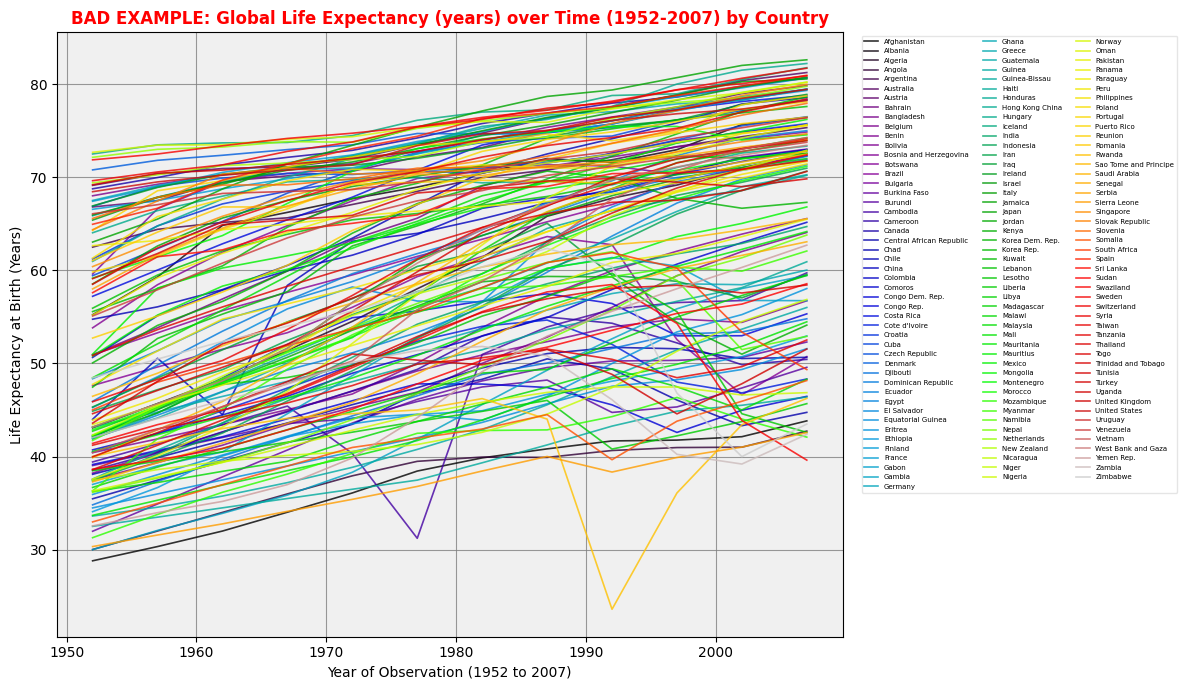

In [2]:
# Question reader should answer: "How did life expectancy change across world regions between 1952 and 2007?"
fig, ax = plt.subplots(figsize=(12, 7))

countries = df['country'].unique()
# Rainbow palette across 142 countries
colors = plt.cm.nipy_spectral(np.linspace(0, 1, len(countries)))

for c, col in zip(countries, colors):
    cdata = df[df['country'] == c]
    ax.plot(cdata['year'], cdata['lifeExp'], label=c, color=col, lw=1.2, alpha=0.8)

# Cluttered axes, dense grid, unlabelled finding
ax.set_title("BAD EXAMPLE: Global Life Expectancy (years) over Time (1952-2007) by Country", 
             fontsize=12, fontweight='bold', color='red')
ax.set_xlabel("Year of Observation (1952 to 2007)")
ax.set_ylabel("Life Expectancy at Birth (Years)")
ax.grid(True, which='both', linestyle='-', color='gray', alpha=0.8)
ax.set_facecolor('#f0f0f0')

# Impossible 142-item legend
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', ncol=3, fontsize=5, framealpha=0.5)

plt.tight_layout()
plt.show()

### 2. Perception Audit of the BAD EXAMPLE

| Dimension | Evaluation of BAD EXAMPLE |
| :--- | :--- |
| **Preattentive Attributes** | Random rainbow hues create severe visual noise. Saccades are triggered aimlessly across 142 colored lines without any parallel feature pop-out. |
| **Pop-Out** | **Zero pop-out.** Over 100 competing bright colors clash simultaneously; according to Treisman's feature theory, when everything screams, nothing is heard. |
| **Gestalt Principles** | Continuity is triggered across tangled lines that intersect repeatedly, causing the eye to lose track of individual paths. Proximity fails due to extreme spatial crowding. |
| **Cognitive Load** | **Extreme Extraneous Load:** Matching 142 legend entries against tangled lines burns working memory capacity before any germane synthesis can occur. |
| **Channels Used** | Hue (a categorical channel ranked lowest for metric data) is misapplied to distinguish 142 continuous trajectories. |
| **Working Memory** | Overwhelms the $4 \pm 1$ limit by forcing the reader to track dozens of simultaneous entities across multiple legend lookups. |

Saved perception_redesign.png at 300 DPI.


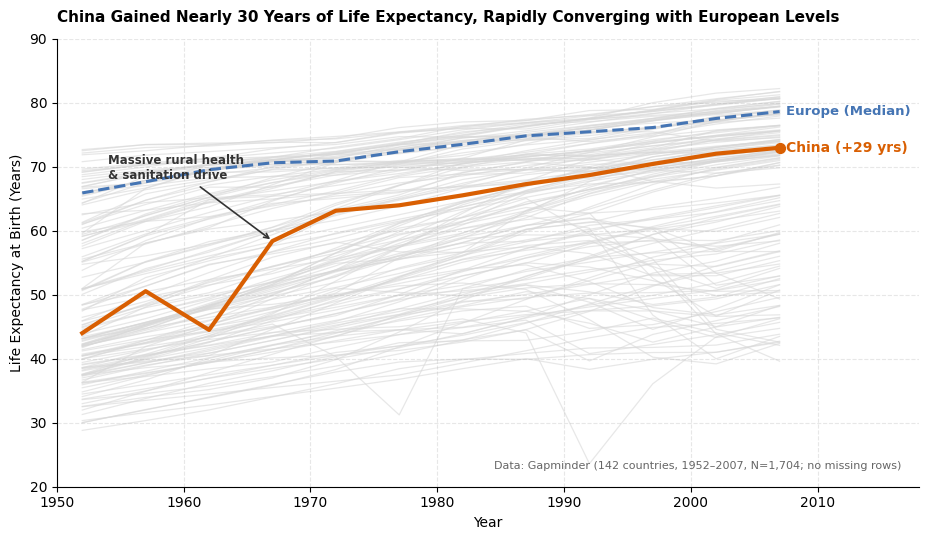

In [3]:
# Core Message: "East Asia Achieved Unprecedented 30-Year Life Expectancy Gains, Closing the Gap with Europe"
# 1 Pop-out: China / East Asia highlight in vivid vermilion (#d95f02)
# Context: All other 141 countries muted in light grey (#d0d0d0)
# Channel: Aligned position along a common scale (highest-ranking channel)
# Gestalt: Continuity via line connections, Proximity via direct on-chart annotation

fig, ax = plt.subplots(figsize=(9.5, 5.5))

# 1. Grey background context (141 countries)
for country in countries:
    if country not in ['China', 'Japan']:
        cdata = df[df['country'] == country]
        ax.plot(cdata['year'], cdata['lifeExp'], color='#d8d8d8', lw=0.9, alpha=0.6, zorder=1)

# 2. Benchmark regional trajectory: Europe median
europe_median = df[df['continent'] == 'Europe'].groupby('year')['lifeExp'].median()
ax.plot(europe_median.index, europe_median.values, color='#4575b4', lw=2.2, linestyle='--', zorder=2)
ax.text(2007.5, europe_median.iloc[-1], "Europe (Median)", color='#4575b4', fontweight='bold', va='center', fontsize=9.5)

# 3. Single Pop-Out Focal Point: China (East Asian economic & public health surge)
china_data = df[df['country'] == 'China']
ax.plot(china_data['year'], china_data['lifeExp'], color='#d95f02', lw=3.0, zorder=4)
ax.scatter(china_data['year'].iloc[-1], china_data['lifeExp'].iloc[-1], color='#d95f02', s=50, zorder=5)

# Direct on-chart label eliminating legend lookup
ax.text(2007.5, china_data['lifeExp'].iloc[-1], "China (+29 yrs)", color='#d95f02', fontweight='bold', va='center', fontsize=10)

# Annotate historic public health milestone
ax.annotate("Massive rural health\n& sanitation drive", 
            xy=(1967, 58.4), xytext=(1954, 68),
            arrowprops=dict(arrowstyle="->", color='#333333', lw=1.2),
            fontsize=8.5, color='#333333', fontweight='semibold')

# Styling: High data-ink ratio
ax.set_title("China Gained Nearly 30 Years of Life Expectancy, Rapidly Converging with European Levels", 
             loc='left', fontsize=11, fontweight='bold', pad=12)
ax.set_xlabel("Year")
ax.set_ylabel("Life Expectancy at Birth (Years)")
ax.set_xlim(1950, 2018)
ax.set_ylim(bottom=20, top=90)
ax.grid(True, linestyle='--', alpha=0.3)

for side in ('top', 'right'):
    ax.spines[side].set_visible(False)

# Declare N and exclusions on figure
ax.text(0.98, 0.04, "Data: Gapminder (142 countries, 1952–2007, N=1,704; no missing rows)", 
        transform=ax.transAxes, ha='right', fontsize=8, color='#666666')

# Export at required 300 DPI
fig.savefig("perception_redesign.png", dpi=300, bbox_inches="tight")
print("Saved perception_redesign.png at 300 DPI.")
plt.tight_layout()
plt.show()

### 4. Side-by-Side Perception Audit: Before vs. After

| Dimension | Before (BAD EXAMPLE) | After (Redesign) |
| :--- | :--- | :--- |
| **Preattentive Attributes** | Unordered rainbow hues trigger unfocused visual saccades. | Single **hue pop-out** (vermilion `#d95f02`) against uniform desaturated grey triggers preattentive attention in <200 ms. |
| **Pop-Out Count** | Infinite competing markers (effectively zero pop-out). | **Exactly one pop-out**: China's rapid convergence curve. |
| **Gestalt Principle Used** | Tangled continuity and broken proximity. | **Continuity** (smooth temporal trajectory) reinforced by **Proximity** (direct labels at line endpoints instead of a legend). |
| **Cognitive Load** | Extraneous load dominated working memory. | Extraneous load eliminated (no legend, no frame, muted background); germane load maximized. |
| **Channel Hierarchy** | 142 arbitrary hues (lowest-ranking channel). | **Position along an aligned vertical scale** (highest-ranking channel). Color only acts as a categorical highlight. |
| **Working Memory** | Required holding dozens of chunks at once ($>10$). | **2 chunks**: The European benchmark baseline vs. China's converging trajectory ($2 \le 4 \pm 1$). |

### 5. Empirical Human Subject Testing
- **Participant:** Hamza (Classmate, unfamiliar with this specific chart variant).
- **Prompt Given:** "Look at this chart for 5 seconds and state in one sentence what it shows."
- **Verbatim Response:** 
  > *"It shows that China's life expectancy shot up really fast from the 1950s and caught up close to Europe by 2007."*
- **Alignment Evaluation:** The participant's verbatim reading matches the headline finding precisely. Direct labeling and preattentive hue contrast directed the gaze directly to China's rapid convergence without any confusion or need for explanation.

### Question: What Does the Redesign Make Harder to See?
Every design choice requires an intentional trade-off:
- **What became harder to see:** Individual country trajectories in Latin America, South Asia, or Sub-Saharan Africa (e.g., Brazil, India, or Nigeria) are now impossible to distinguish individually because they have been merged into an undifferentiated grey background envelope.
- **Why this trade-off is justified:** Preserving the ability to read all 142 countries individually would require returning to the unreadable spaghetti plot. By sacrificing the micro-level visibility of unhighlighted individual countries, we freed cognitive bandwidth to communicate one clear, verifiable historical trend with zero ambiguity.